# Układy Dynamiczne 7
## Paweł Drzyzga

# Zadanie 1

Rozważamy model Rickera:

$$
x_{n+1}=f(x_n)=x_n e^{r(1-x_n)}, \qquad r>0
$$

Mamy zbadać **punkty równowagi** i ich stabilność.

---

# 1. Punkty równowagi

Punkt równowagi spełnia:

$$
f(x)=x
$$

czyli

$$
x e^{r(1-x)}=x
$$

Stąd:

$$
x=0
\quad \text{lub} \quad
e^{r(1-x)}=1
$$

Ponieważ $e^y=1 \iff y=0$, więc:

$$
r(1-x)=0
$$

a ponieważ $r>0$, dostajemy:

$$
x=1
$$

## Punkty równowagi:

$$
\boxed{x=0,; x=1}
$$

---

# 2. Kryterium stabilności

Jeśli dla punktu równowagi $a$:

$$
|f'(a)|<1
$$

to punkt jest asymptotycznie stabilny.

Jeśli:

$$
|f'(a)|>1
$$

to niestabilny.

---

# 3. Pochodna funkcji

$$
f(x)=x e^{r(1-x)}
$$

Liczymy pochodną:

$$
f'(x)=e^{r(1-x)}+x\cdot e^{r(1-x)}(-r)
$$

$$
f'(x)=e^{r(1-x)}(1-rx)
$$

---

# 4. Stabilność punktu $x=0$

$$
f'(0)=e^{r}(1-0)=e^r
$$

Ponieważ dla $r>0$:

$$
e^r>1
$$

więc:

$$
|f'(0)|>1
$$

Zatem:

$$
\boxed{x=0 \text{ jest niestabilny dla każdego } r>0}
$$

---

# 5. Stabilność punktu $x=1$

$$
f'(1)=e^{0}(1-r)=1-r
$$

Badamy:

$$
|1-r|<1
$$

czyli:

$$
-1<1-r<1
$$

Lewa strona:

$$
-1<1-r \iff r<2
$$

Prawa strona:

$$
1-r<1 \iff r>0
$$

A więc:

$$
0<r<2
$$

Zatem:

$$
\boxed{x=1 \text{ jest asymptotycznie stabilny dla } 0<r<2}
$$

---

# 6. Przypadek graniczny $r=2$

Wtedy:

$$
f'(1)=1-2=-1
$$

Ponieważ moduł = 1, test pochodnej nie rozstrzyga.

To przypadek graniczny – zwykle pojawia się oscylacja i utrata stabilności (bifurkacja okresu 2).

---

# 7. Dla $r>2$

$$
|1-r|>1
$$

więc:

$$
\boxed{x=1 \text{ jest niestabilny dla } r>2}
$$

---

# Ostateczna odpowiedź

Punkty równowagi modelu Rickera:

$$
\boxed{x=0,;x=1}
$$

Ich stabilność:

* $\boxed{x=0}$ — niestabilny dla każdego $r>0$

* $\boxed{x=1}$:

$$
\begin{cases}

\text{asymptotycznie stabilny}, & 0<r<2 \\

\text{przypadek graniczny}, & r=2 \\

\text{niestabilny}, & r>2

\end{cases}
$$

---

# Intuicja biologiczna

* $x=0$: wymarcie populacji — niestabilne, bo mała populacja rośnie.
* $x=1$: poziom równowagi populacji.
* małe $r$: spokojne dojście do równowagi,
* większe $r$: oscylacje,
* duże $r$: chaos dynamiczny.


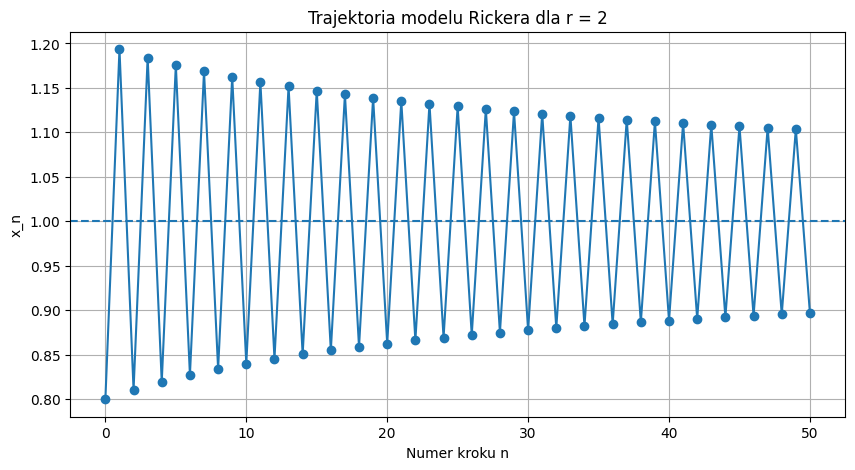

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# parametr modelu Rickera - przypadek graniczny
r = 2.0

# warunek początkowy
x0 = 0.8

# liczba iteracji
n_steps = 50

# tablica na trajektorię
x = np.zeros(n_steps + 1)
x[0] = x0

# iteracja
for n in range(n_steps):
    x[n + 1] = x[n] * np.exp(r * (1 - x[n]))

# wykres trajektorii
plt.figure(figsize=(10, 5))
plt.plot(range(n_steps + 1), x, marker='o')
plt.axhline(1.0, linestyle='--')
plt.xlabel("Numer kroku n")
plt.ylabel("x_n")
plt.title("Trajektoria modelu Rickera dla r = 2")
plt.grid(True)
plt.show()

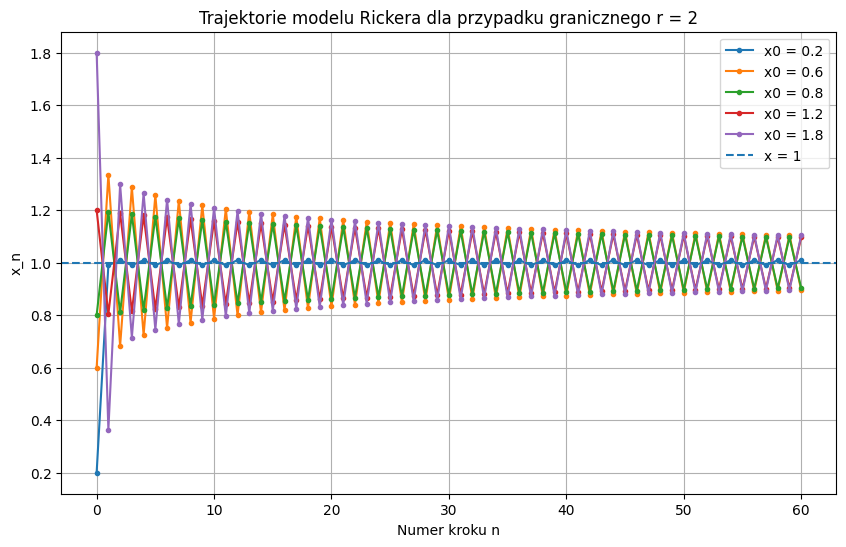

In [2]:
import numpy as np
import matplotlib.pyplot as plt

r = 2.0
n_steps = 60
initial_conditions = [0.2, 0.6, 0.8, 1.2, 1.8]

plt.figure(figsize=(10, 6))

for x0 in initial_conditions:
    x = np.zeros(n_steps + 1)
    x[0] = x0
    
    for n in range(n_steps):
        x[n + 1] = x[n] * np.exp(r * (1 - x[n]))
    
    plt.plot(range(n_steps + 1), x, marker='o', markersize=3, label=f"x0 = {x0}")

plt.axhline(1.0, linestyle='--', label='x = 1')
plt.xlabel("Numer kroku n")
plt.ylabel("x_n")
plt.title("Trajektorie modelu Rickera dla przypadku granicznego r = 2")
plt.grid(True)
plt.legend()
plt.show()

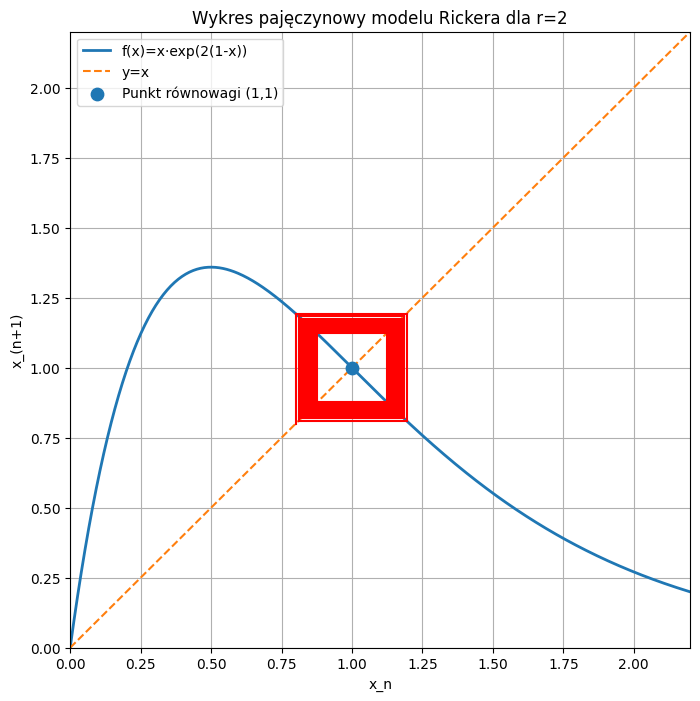

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Model Rickera - wykres pajęczynowy
# przypadek graniczny r = 2
# ===============================

r = 2.0
x0 = 0.8          # punkt startowy
n_iter = 30       # liczba iteracji

# funkcja modelu Rickera
def f(x):
    return x * np.exp(r * (1 - x))

# zakres osi
x_vals = np.linspace(0, 2.2, 500)

# rysowanie funkcji i=y=x
plt.figure(figsize=(8,8))
plt.plot(x_vals, f(x_vals), label="f(x)=x·exp(2(1-x))", linewidth=2)
plt.plot(x_vals, x_vals, "--", label="y=x")

# start iteracji
x = x0

for _ in range(n_iter):
    y = f(x)

    # pionowo do wykresu funkcji
    plt.plot([x, x], [x, y], color="red")

    # poziomo do prostej y=x
    plt.plot([x, y], [y, y], color="red")

    x = y

# zaznaczenie punktu równowagi x=1
plt.scatter([1], [1], s=80, zorder=5, label="Punkt równowagi (1,1)")

plt.xlim(0, 2.2)
plt.ylim(0, 2.2)
plt.xlabel("x_n")
plt.ylabel("x_(n+1)")
plt.title("Wykres pajęczynowy modelu Rickera dla r=2")
plt.grid(True)
plt.legend()
plt.show()

### Zastosowanie Modelu Rickera

Model Rickera dany wzorem

$$
x_{n+1}=x_n e^{r(1-x_n)}
$$

jest klasycznym dyskretnym modelem dynamiki populacji, stosowanym do opisu liczebności populacji w kolejnych sezonach rozrodczych. Zakłada on, że tempo wzrostu populacji maleje wraz ze wzrostem zagęszczenia osobników, co odpowiada ograniczonym zasobom środowiska, takim jak pożywienie, przestrzeń czy dostępność siedlisk.

Model ten znajduje zastosowanie przede wszystkim w:

* ekologii populacyjnej, do opisu liczebności ryb, owadów oraz innych gatunków o sezonowym cyklu życia,
* biologii zasobów naturalnych, przy analizie eksploatacji populacji i ryzyka przełowienia,
* badaniach dynamiki nieliniowej, ponieważ dla większych wartości parametru (r) model może wykazywać oscylacje, bifurkacje oraz zachowania chaotyczne,
* matematyce stosowanej jako przykład prostego układu dyskretnego o bogatej dynamice.

Model Rickera jest szczególnie ceniony, ponieważ mimo prostej postaci matematycznej dobrze pokazuje przejście od stabilnej równowagi do nieregularnych zmian liczebności populacji.

---

# Zadanie 6

Mamy model Shepherda w postaci

$$
f(x)=\frac{rx}{1+x^2},
$$

czyli ciąg dany rekurencyjnie przez

$$
a_{n+1}=\frac{r a_n}{1+a_n^2}.
$$

W treści pojawia się też informacja (c=2), co zgadza się z tym wzorem, bo ogólnie model Shepherda zapisuje się jako

$$
f(x)=\frac{rx}{1+x^c},
$$

a tutaj po prostu podstawiono (c=2).

---

# a) Punkty równowagi

Szukamy wszystkich (x), dla których

$$
f(x)=x.
$$

Zatem

$$
\frac{rx}{1+x^2}=x.
$$

Przenosimy wszystko na jedną stronę:

$$
\frac{rx}{1+x^2}-x=0.
$$

Wyłączamy (x):

$$
x\left(\frac{r}{1+x^2}-1\right)=0.
$$

Stąd mamy dwa przypadki.

## Przypadek 1

$$
x=0.
$$

## Przypadek 2

$$
\frac{r}{1+x^2}=1.
$$

Czyli

$$
r=1+x^2,
$$

więc

$$
x^2=r-1.
$$

A zatem

$$
x=\pm\sqrt{r-1}.
$$

---

## Wniosek matematyczny

Wszystkie punkty równowagi to:

$$
\boxed{x=0 \quad \text{oraz} \quad x=\pm\sqrt{r-1}}
$$

o ile (r\ge 1).

---

## Wniosek biologiczny

Ponieważ mówimy o populacji, interesują nas zwykle tylko wartości (x\ge 0). Wtedy:

* zawsze mamy punkt równowagi (x=0),
* dla (r\ge 1) mamy także nietrywialny punkt równowagi

$$
\boxed{x^*=\sqrt{r-1}}.
$$

---

# Stabilność punktów równowagi

Liczymy pochodną:

$$
f(x)=\frac{rx}{1+x^2}.
$$

Korzystamy z reguły ilorazu:

$$
f'(x)=\frac{r(1+x^2)-rx\cdot 2x}{(1+x^2)^2}
=\frac{r+rx^2-2rx^2}{(1+x^2)^2}.
$$

Po uproszczeniu:

$$
f'(x)=\frac{r(1-x^2)}{(1+x^2)^2}.
$$

---

## Punkt (x=0)

Mamy

$$
f'(0)=r.
$$

Zatem:

* jeśli (|r|<1), to (x=0) jest asymptotycznie stabilny,
* jeśli (|r|>1), to (x=0) jest niestabilny.

Ponieważ w modelu populacyjnym zwykle zakładamy (r>0), to:

* dla (0<r<1): (x=0) stabilny,
* dla (r>1): (x=0) niestabilny.

---

## Nietrywialny punkt równowagi (x^*=\sqrt{r-1})

Podstawiamy (x^2=r-1) do pochodnej:

$$
f'(x^*)=\frac{r(1-(r-1))}{(1+(r-1))^2}.
$$

Czyli

$$
f'(x^*)=\frac{r(2-r)}{r^2}=\frac{2-r}{r}.
$$

Zatem punkt nietrywialny jest stabilny, gdy

$$
\left|\frac{2-r}{r}\right|<1.
$$

Dla (r>0) daje to po prostu

$$
r>1.
$$

Czyli dla dodatnich parametrów:

$$
\boxed{\text{nietrywialny punkt równowagi jest asymptotycznie stabilny dla } r>1.}
$$

To ważne, bo w obu podpunktach b i c mamy właśnie (r=2) i (r=10), więc w obu przypadkach punkt nietrywialny powinien być stabilny.

---

# b) (a_1=4,; r=2)

Rekurencja ma postać

$$
a_{n+1}=\frac{2a_n}{1+a_n^2}.
$$

Punkt nietrywialny wynosi

$$
x^*=\sqrt{2-1}=1.
$$

Liczymy kolejne pięć wyrazów po (a_1), czyli (a_2,a_3,a_4,a_5,a_6).

## Krok 1

$$
a_2=\frac{2\cdot 4}{1+4^2}=\frac{8}{17}\approx 0.470588.
$$

## Krok 2

$$
a_3=\frac{2a_2}{1+a_2^2}\approx 0.770538.
$$

## Krok 3

$$
a_4=\frac{2a_3}{1+a_3^2}\approx 0.966963.
$$

## Krok 4

$$
a_5=\frac{2a_4}{1+a_4^2}\approx 0.999436.
$$

## Krok 5

$$
a_6=\frac{2a_5}{1+a_5^2}\approx 0.99999984.
$$

---

## Wniosek dla b)

Otrzymujemy:

$$
4,; 0.470588,; 0.770538,; 0.966963,; 0.999436,; 0.99999984,\dots
$$

Ciąg wyraźnie dąży do (1), więc nietrywialny punkt równowagi

$$
\boxed{x^*=1}
$$

wydaje się stabilny. I to zgadza się z obliczeniem pochodnej, bo

$$
f'(1)=\frac{2-2}{2}=0.
$$

To nawet silna stabilność lokalna.

---

# c) (a_1=4,; r=10)

Teraz mamy

$$
a_{n+1}=\frac{10a_n}{1+a_n^2}.
$$

Nietrywialny punkt równowagi to

$$
x^*=\sqrt{10-1}=3.
$$

Liczymy pięć kolejnych wyrazów.

## Krok 1

$$
a_2=\frac{10\cdot 4}{1+4^2}=\frac{40}{17}\approx 2.352941.
$$

## Krok 2

$$
a_3=\frac{10a_2}{1+a_2^2}\approx 3.599788.
$$

## Krok 3

$$
a_4=\frac{10a_3}{1+a_3^2}\approx 2.578927.
$$

## Krok 4

$$
a_5=\frac{10a_4}{1+a_4^2}\approx 3.370766.
$$

## Krok 5

$$
a_6=\frac{10a_5}{1+a_5^2}\approx 2.726702.
$$

---

## Wniosek dla c)

Dostajemy:

$$
4,; 2.352941,; 3.599788,; 2.578927,; 3.370766,; 2.726702,\dots
$$

Widać oscylacje wokół wartości (3), ale nie uciekanie od niej. To sugeruje, że punkt nietrywialny

$$
\boxed{x^*=3}
$$

jest stabilny.

I rzeczywiście:

$$
f'(3)=\frac{2-10}{10}=-\frac{8}{10}=-0.8,
$$

więc

$$
|f'(3)|=0.8<1.
$$

Punkt jest asymptotycznie stabilny, ale ponieważ pochodna jest ujemna, zbieżność odbywa się oscylacyjnie.

---

# d) Diagram pajęczynowy dla punktu b)

Tutaj (r=2), więc

$$
f(x)=\frac{2x}{1+x^2}.
$$

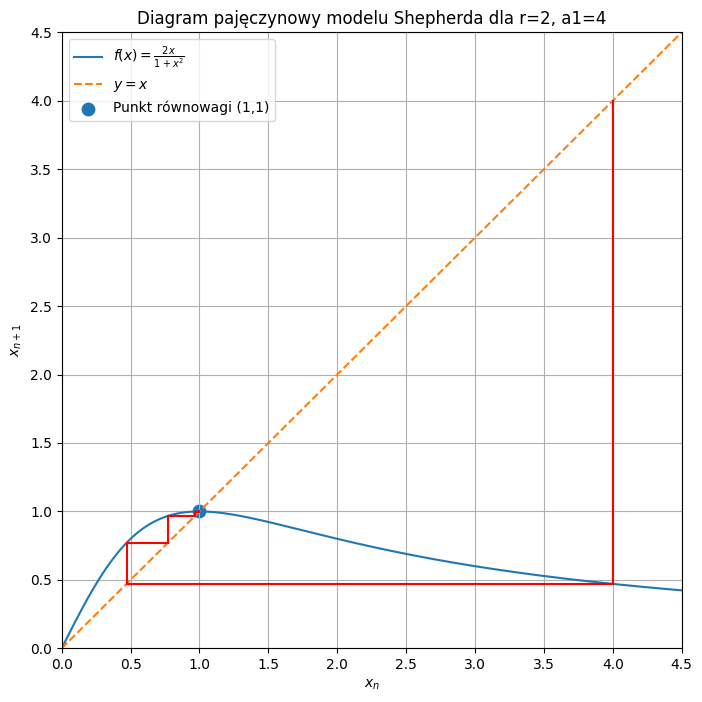

In [4]:
import numpy as np
import matplotlib.pyplot as plt

r = 2
a1 = 4
n_iter = 20

def f(x):
    return r * x / (1 + x**2)

x_vals = np.linspace(0, 4.5, 500)

plt.figure(figsize=(8, 8))
plt.plot(x_vals, f(x_vals), label=r"$f(x)=\frac{2x}{1+x^2}$")
plt.plot(x_vals, x_vals, "--", label=r"$y=x$")

x = a1
for _ in range(n_iter):
    y = f(x)
    plt.plot([x, x], [x, y], color="red")
    plt.plot([x, y], [y, y], color="red")
    x = y

plt.scatter([1], [1], s=80, label="Punkt równowagi (1,1)")
plt.xlim(0, 4.5)
plt.ylim(0, 4.5)
plt.xlabel(r"$x_n$")
plt.ylabel(r"$x_{n+1}$")
plt.title("Diagram pajęczynowy modelu Shepherda dla r=2, a1=4")
plt.grid(True)
plt.legend()
plt.show()

# e) Diagram pajęczynowy dla punktu c)

Tutaj (r=10), więc

$$
f(x)=\frac{10x}{1+x^2}.
$$

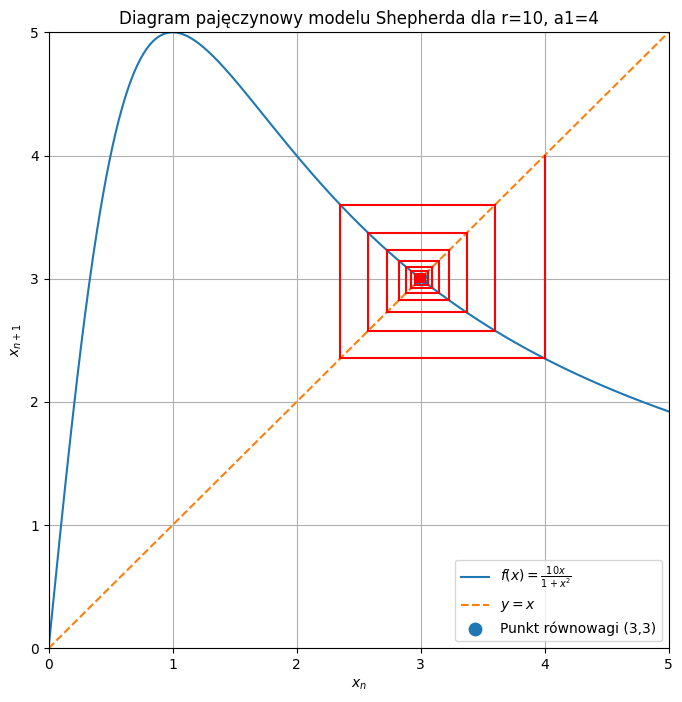

In [5]:
import numpy as np
import matplotlib.pyplot as plt

r = 10
a1 = 4
n_iter = 30

def f(x):
    return r * x / (1 + x**2)

x_vals = np.linspace(0, 5, 600)

plt.figure(figsize=(8, 8))
plt.plot(x_vals, f(x_vals), label=r"$f(x)=\frac{10x}{1+x^2}$")
plt.plot(x_vals, x_vals, "--", label=r"$y=x$")

x = a1
for _ in range(n_iter):
    y = f(x)
    plt.plot([x, x], [x, y], color="red")
    plt.plot([x, y], [y, y], color="red")
    x = y

plt.scatter([3], [3], s=80, label="Punkt równowagi (3,3)")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel(r"$x_n$")
plt.ylabel(r"$x_{n+1}$")
plt.title("Diagram pajęczynowy modelu Shepherda dla r=10, a1=4")
plt.grid(True)
plt.legend()
plt.show()

## Punkty równowagi

Matematycznie:

$$
\boxed{x=0 \quad \text{oraz} \quad x=\pm\sqrt{r-1}}
$$

dla (r\ge 1).

W interpretacji populacyjnej:

$$
\boxed{x=0 \quad \text{oraz} \quad x=\sqrt{r-1}}
$$

---

## Dla (r=2)

Nietrywialny punkt równowagi:

$$
\boxed{x^*=1}
$$

Kolejne wyrazy od (a_1=4):

$$
a_2\approx 0.470588,\quad
a_3\approx 0.770538,\quad
a_4\approx 0.966963,\quad
a_5\approx 0.999436,\quad
a_6\approx 0.99999984.
$$

Wniosek:

$$
\boxed{x^*=1 \text{ jest stabilny}}
$$

---

## Dla (r=10)

Nietrywialny punkt równowagi:

$$
\boxed{x^*=3}
$$

Kolejne wyrazy od (a_1=4):

$$
a_2\approx 2.352941,\quad
a_3\approx 3.599788,\quad
a_4\approx 2.578927,\quad
a_5\approx 3.370766,\quad
a_6\approx 2.726702.
$$

Wniosek:

$$
\boxed{x^*=3 \text{ jest stabilny}}
$$

przy czym zbieżność ma charakter oscylacyjny.

# Przypadek b: (a_1=4,; r=2)

Wtedy

$$
a_{n+1}=\frac{2a_n}{1+a_n^2}.
$$

Kolejne wyrazy trajektorii:

$$
a_1=4
$$

$$
a_2=\frac{8}{17}\approx 0.470588
$$

$$
a_3\approx 0.770538
$$

$$
a_4\approx 0.966963
$$

$$
a_5\approx 0.999436
$$

$$
a_6\approx 0.99999984
$$

$$
a_7\approx 1.00000000
$$

$$
a_8\approx 1.00000000
$$

Zatem początek trajektorii można zapisać jako

$$
4,;0.470588,;0.770538,;0.966963,;0.999436,;0.99999984,;1,;1,\dots
$$

Widać bardzo szybkie dążenie do punktu równowagi

$$
x^*=1.
$$

---

# Przypadek c: (a_1=4,; r=10)

Wtedy

$$
a_{n+1}=\frac{10a_n}{1+a_n^2}.
$$

Kolejne wyrazy trajektorii:

$$
a_1=4
$$

$$
a_2=\frac{40}{17}\approx 2.352941
$$

$$
a_3\approx 3.599788
$$

$$
a_4\approx 2.578927
$$

$$
a_5\approx 3.370766
$$

$$
a_6\approx 2.726702
$$

$$
a_7\approx 3.211562
$$

$$
a_8\approx 2.842909
$$

$$
a_9\approx 3.122455
$$

$$
a_{10}\approx 2.909715
$$

$$
a_{11}\approx 3.071388
$$

$$
a_{12}\approx 2.948486
$$

Zatem trajektoria zaczyna się od

$$
4,;2.352941,;3.599788,;2.578927,;3.370766,;2.726702,;3.211562,;2.842909,;3.122455,;2.909715,;3.071388,;2.948486,\dots
$$

Tutaj widać oscylacyjne zbliżanie się do punktu równowagi

$$
x^*=3.
$$


Dla wartości początkowej (a_1=4) i parametru (r=2) trajektoria bardzo szybko zbiega do nietrywialnego punktu równowagi (x^*=1). Natomiast dla (r=10) trajektoria również dąży do nietrywialnego punktu równowagi (x^*=3), ale w sposób oscylacyjny, na przemian przyjmując wartości większe i mniejsze od (3).


### Zastosowanie Modelu Shepherda

Model Shepherda w rozważanej postaci

$$
x_{n+1}=\frac{r x_n}{1+x_n^2}
$$

jest również modelem dynamiki populacji, opisującym wzrost populacji przy jednoczesnym działaniu mechanizmów ograniczających rozwój. W porównaniu z modelem Rickera, efekt zagęszczenia populacji pojawia się tutaj w mianowniku funkcji wzrostu, co prowadzi do innego rodzaju hamowania wzrostu liczebności.

Model Shepherda stosowany jest głównie w:

* ekologii i biologii populacyjnej, do opisu populacji podlegających konkurencji wewnętrznej,
* rybołówstwie i gospodarce zasobami odnawialnymi, do modelowania rekrutacji nowych osobników do populacji,
* analizie stabilności układów dyskretnych, gdzie bada się istnienie punktów równowagi i zbieżność trajektorii,
* modelowaniu procesów samoregulujących się, w których wzrost maleje wraz ze wzrostem stanu układu.

Model Shepherda jest użyteczny wtedy, gdy zależność między liczebnością populacji a tempem wzrostu nie jest wykładnicza, lecz raczej racjonalna, co bywa lepszym przybliżeniem w niektórych zastosowaniach biologicznych.

---

### Porównanie modeli

Zarówno model Rickera, jak i model Shepherda służą do opisu zmian liczebności populacji w czasie dyskretnym, jednak różnią się sposobem modelowania wpływu zagęszczenia populacji na tempo wzrostu:

* model Rickera wykorzystuje czynnik wykładniczy,
* model Shepherda wykorzystuje funkcję wymierną.

Oba modele są szeroko wykorzystywane w ekologii teoretycznej oraz jako przykłady układów dynamicznych w analizie matematycznej.